In [55]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [56]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [57]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
          return None
        return self.solution.path_cost

In [58]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent
    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [59]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
          return state == self.goal
          raise NotImplementedError("Complete GridProblem.is_goal")
    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []
        for action in MOVES:
          new_row = state[0] + MOVES[action][0]
          new_col = state [1] + MOVES[action][1]
          neighbour = (new_row, new_col)
          if self.in_bounds(neighbour) and self.is_free(neighbour):
            legal_actions.append(action)
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        dr, dc = MOVES[action]
        next_row = state[0] + dr
        next_col = state[1] + dc
        next_state = (next_row, next_col)
        return next_state
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
    # TODO 4:
    # In this lab, each valid move has a cost of 1.
    # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")


In [60]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [61]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

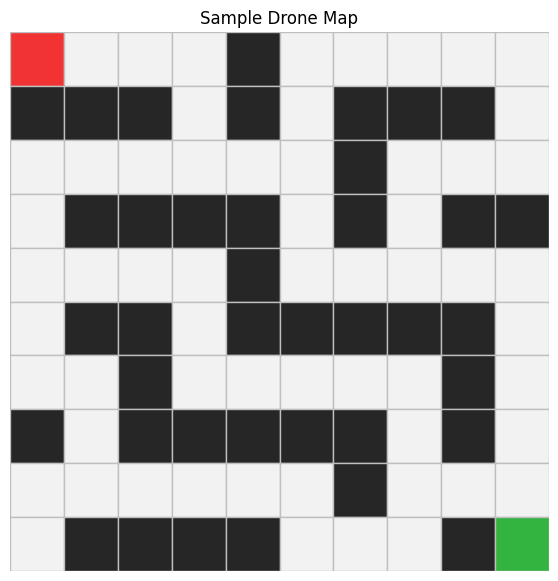

In [62]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [63]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
          s_prime = problem.result(s, action)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state = s_prime, parent=node, action = action, path_cost = cost)
        #raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [64]:
 class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
          return SearchResult(algorithm="BFS", status="success", solution=node,
                        nodes_expanded=0, max_frontier_size=1, reached_count=1)
        frontier = deque([node])
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = 1
        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1
            for child in self.expand(problem, node):
              s = child.state
              if problem.is_goal(s):
                  return SearchResult(algorithm="BFS", status="success", solution=child,
                                nodes_expanded=nodes_expanded,
                                max_frontier_size=max_frontier_size,
                                reached_count=len(reached))
              if s not in reached:
                reached.add(s)
                frontier.append(child)
                self.max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(algorithm="BFS", status="failure", solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached))
        #raise NotImplementedError("Complete BreadthFirstSearch.search")

In [65]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(algorithm="DFS", status="success", solution=node,
                        nodes_expanded=0, max_frontier_size=1,
                        reached_count=1)

        frontier = [node]
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = 1
        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in reversed(list(self.expand(problem, node))):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(algorithm="DFS", status="success", solution=child,
                                nodes_expanded=nodes_expanded,
                                max_frontier_size=max_frontier_size,
                                reached_count=len(reached))

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(algorithm="DFS", status="failure", solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached))
        #raise NotImplementedError("Complete DepthFirstSearch.search")

In [66]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return (node, "success")
        elif node.depth >= limit:
             return (None, "cutoff")
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occured = False

            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue
                metrics["max_stack_size"] = max(
                metrics["max_stack_size"],
                current_stack_size + 1)
                result, status = self._recursive_dls(problem=problem, node=child,
                      limit=limit,metrics=metrics,
                      current_stack_size=current_stack_size + 1)
                if status == "success":
                    return (result, "success")
                elif status == "cutoff":
                    cutoff_occured = True
            if cutoff_occured:
                  return (None, "cutoff")
            else:
                return (None, "failure")
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        #raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [67]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        iteration_log = []
        total_nodes_expanded = 0
        overall_max_stack_size = 0

        for limit in range(max_depth + 1):

            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            iteration_log.append((limit, result.status))

            total_nodes_expanded += result.nodes_expanded

            overall_max_stack_size = max(
                overall_max_stack_size,
                result.max_frontier_size )

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_stack_size,
                    reached_count=0,
                    limit=limit )

            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_stack_size,
                    reached_count=0,
                    limit=limit )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=overall_max_stack_size,
            reached_count=0,
            limit=max_depth )
        #raise NotImplementedError("Complete IterativeDeepeningSearch.search")

In [68]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,1,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


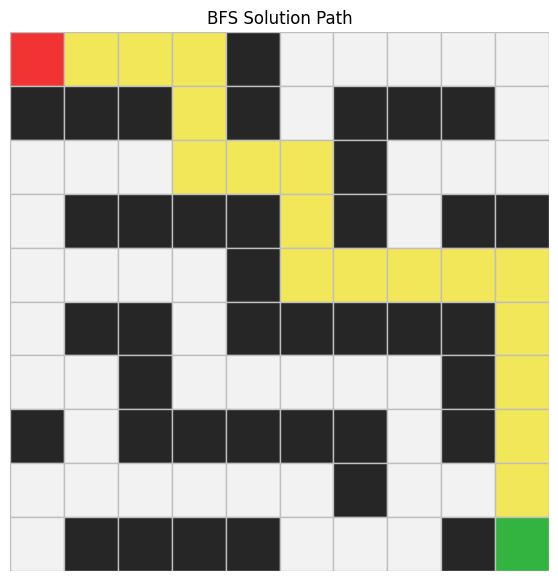

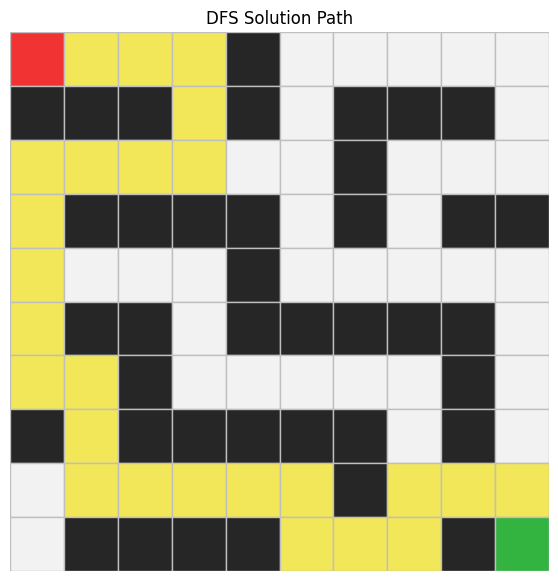

In [69]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [70]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()
custom_result_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit = 20),
    ids.search(custom_problem_1, max_depth = 40)
]

show_results(custom_result_1)


# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
# show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,28.0,28.0,143,1,144
1,DFS,success,NaN,50.0,50.0,68,12,78
2,DLS,cutoff,20.0,NaN,NaN,462,21,0
3,IDS,success,28.0,28.0,28.0,12130,29,0


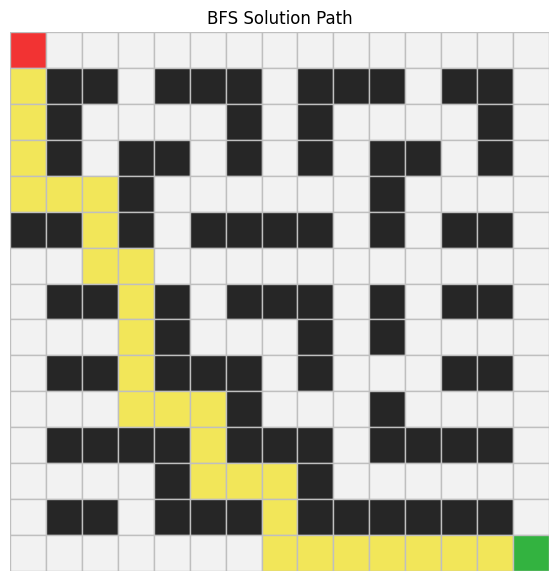

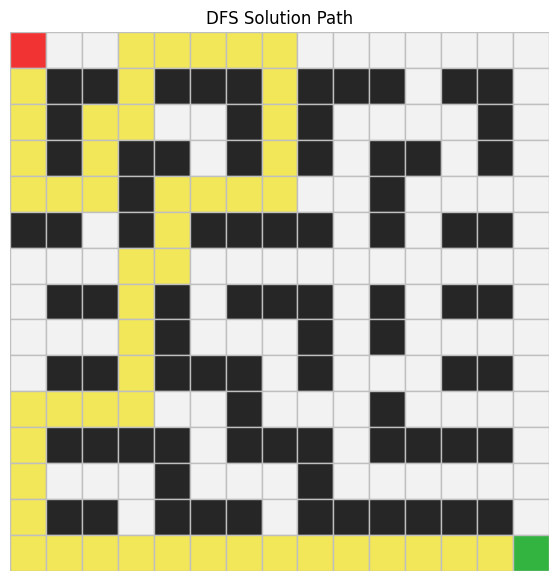

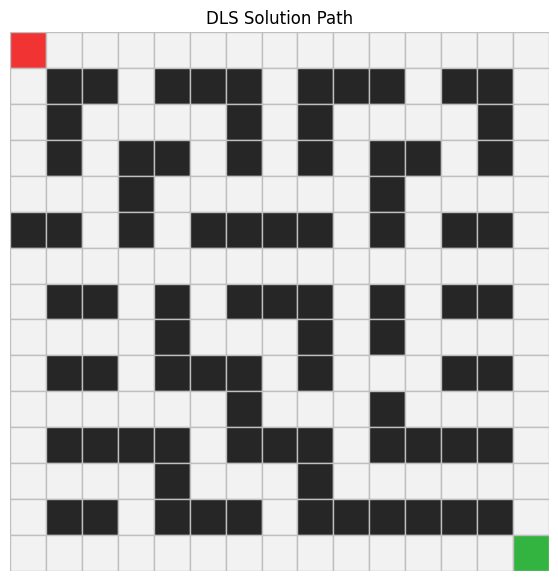

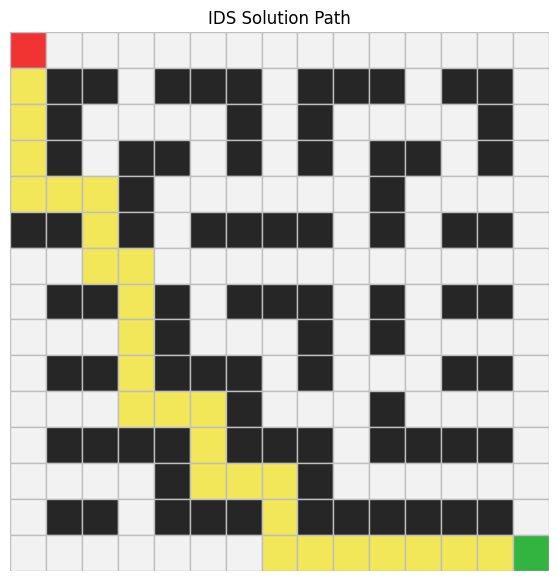

In [71]:
bfs_result = custom_result_1[0]
dfs_result = custom_result_1[1]
dls_result = custom_result_1[2]
ids_result = custom_result_1[3]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path = bfs_result.path,
    title = "BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path = dfs_result.path,
    title = "DFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path = dls_result.path,
    title = "DLS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path = ids_result.path,
    title = "IDS Solution Path",
)


In [72]:
custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

]

custom_start_2 = (0, 0)
custom_goal_2 = (10, 13)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()
custom_result_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit = 20),
    ids.search(custom_problem_2, max_depth = 40)
]

show_results(custom_result_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,23.0,23.0,97,1,100
1,DFS,success,NaN,63.0,63.0,70,12,81
2,DLS,cutoff,20.0,NaN,NaN,190,21,0
3,IDS,success,23.0,23.0,23.0,1805,24,0


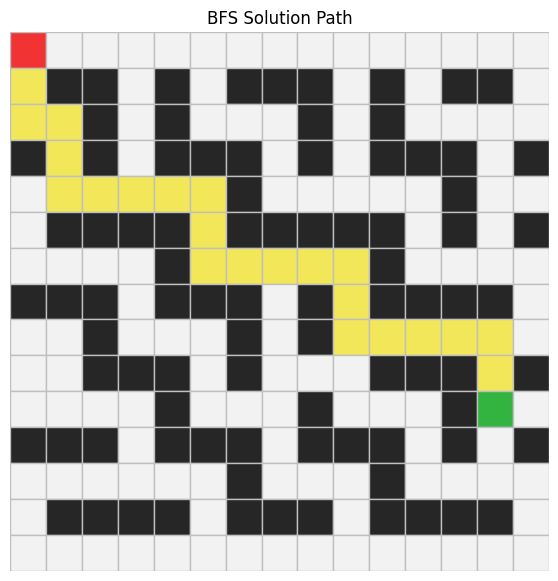

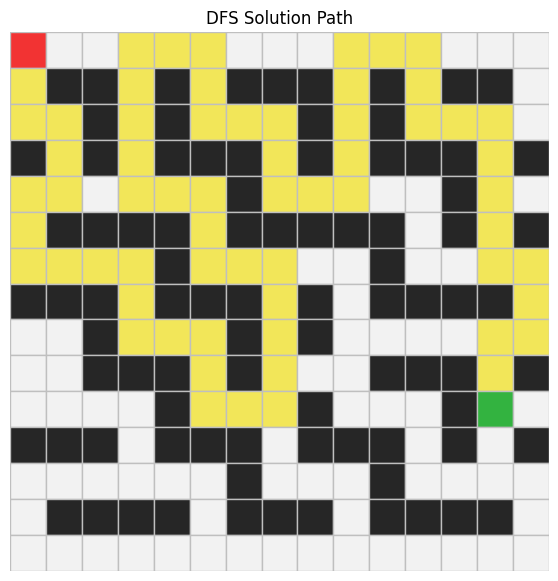

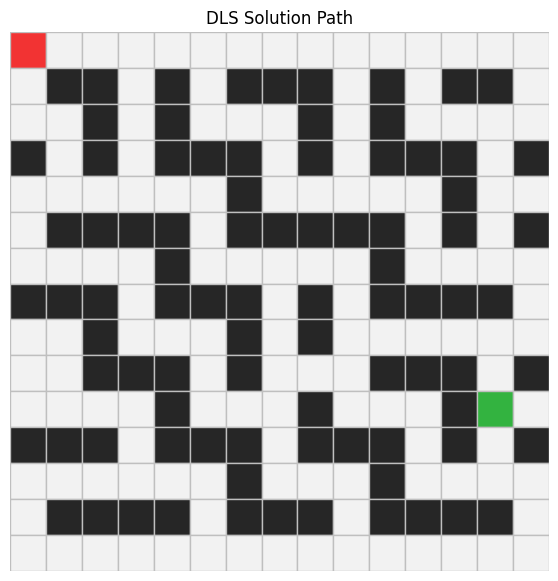

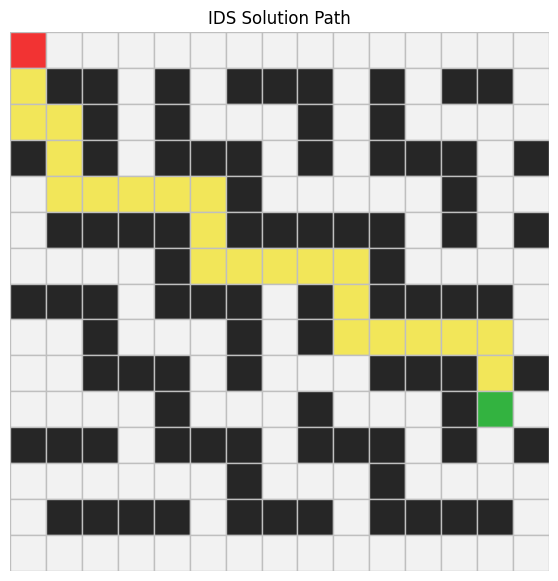

In [73]:
bfs_result = custom_result_2[0]
dfs_result = custom_result_2[1]
dls_result = custom_result_2[2]
ids_result = custom_result_2[3]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path = bfs_result.path,
    title = "BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path = dfs_result.path,
    title = "DFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path = dls_result.path,
    title = "DLS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path = ids_result.path,
    title = "IDS Solution Path",
)

In [74]:
# 15.1 Problem Formulation
# What is a state in this lab?
"""A state is the current location of the drone on the grid """
# What is an action?
"""An action is a posibble decision or step the drone can take to move to the next state on the grid which is a free"""
# What does the result function do?
"""The result function takes in a state and an action that can be performed on that particular state
 to get the next state the drone can be in"""
# Why is it useful to separate the problem definition from the search algorithm?
""" The avoid hard coding such that the algorithms can work on different problems without
having to change the implementation of the codes in the search problems all over again"""

' The avoid hard coding such that the algorithms can work on different problems without\nhaving to change the implementation of the codes in the search problems all over again'

In [75]:
# 15.2 BFS
# Why does BFS use a FIFO queue?
""" A FIFO queue is used because BFS have to expand nodes that are first in the frontier before expanding later nodes and
in the FIFO queue nodes are added at the back and removed at the front, meaning earlier discovered nodes are always explored  """
# Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
"""Because BFS explores all paths of length 1 first, then all paths of length 2, and so on. This means the first time BFS reaches the goal,
it must have gotten there in the fewest possible steps because it has already checked every shorter path before it.
 On an unweighted grid every move costs the same so fewest steps means shortest path."""
# What role does the reached set play in BFS?
"""It keeps track of all the states that have been visited and makes sure that no state is added twice to the set such that
the algorithm do not run in cycles."""

'It keeps track of all the states that have been visited and makes sure that no state is added twice to the set such that\nthe algorithm do not run in cycles.'

In [76]:
# 15.3 DFS
# Why does DFS use a stack?
"""Because a stack uses the Last in first out (LIFO) format to
exapnd the nodes to make sure that last nodes are explored in depth before moving to the next node """
# Is DFS guaranteed to find the shortest path? Explain.
"""No it is not guaranteed to find the shortest path because DFS explores the nodes deeper and indepth
without caring about the length at which it is going like in the second custom grid example the BFS uses
23 solution depth before finding the goal while the DFS uses 63 claerly showing that the DFS uses more depth
to find the goal and not the shortest path"""
# Under what conditions can DFS use less memory than BFS?
"""DFS uses less memory than the BFS when the goal is deep in the search in this case the DFS only keeps the
current path in memory while the BFS keeps all the current nodes in the frontier which sometimes grow larger"""
# Under what conditions can DFS perform badly?
"""When the problem has a very stip path that leads away from the goal, in this case DFS has to explore all
the nodes down before returning back again to look for the solution. Also when the path has so many dead ends  """

'When the problem has a very stip path that leads away from the goal, in this case DFS has to explore all\nthe nodes down before returning back again to look for the solution. Also when the path has so many dead ends  '

In [77]:
# 15.4 DLS
# What happens when the depth limit is too small?
"""When the depth limit is small and the goal is at far down of the prolem then meaning the algorithm cannot find the goal because
it will terminate even before reaching the goal state"""
# What is the meaning of "cutoff"?
"""Cutoff means the algorithm has reached the depth limit and has stopped"""
# How is DLS different from ordinary DFS?
"""DLS keeps going deeper and down the grid or problem untill it finds the solution or untill it reaches the end of the grid or problem,
while the DLS stops immediately it reaches the depth limit, even if it hasn't found the goal to the problem"""
# Why do we use path-cycle checking in DLS?
"""So that DLS can revisit the same state on different paths so as to not miss solutions that go through the same state
at a different depth"""

'So that DLS can revisit the same state on different paths so as to not miss solutions that go through the same state\nat a different depth'

In [78]:
# 15.5 IDS
# Why does IDS repeat DLS with increasing limits?
"""Because IDS don't know how deep the goal is s it uses DLS starting with a smaller depth limit and increasing till it finds thet solution. """
# Why can IDS be complete even though DLS with a small limit is not?
""" Because IDS goes all the way to down of the problem unless it finds the goal and it stops so even in the worst case IDS still finds the goal but DLS only finds the the goal when it is withing the depth limit and if it is not then DLS does not find the goal."""
# Why does IDS use less memory than BFS?
"""Because DFS works just like DFS and it only keeps the current path in memory where as BFS keeps all the reached but yet to exapnd nodes in the frontier."""
# What is the cost of repeatedly searching from the root?
"""The cost is repeatedly searching nodes many times."""

'The cost is repeatedly searching nodes many times.'

In [79]:
# 15.6 Real-World Drone Context
# In a real drone application, what might make one route safer or more practical than another?
"""Weather conditions: Strong winds and rain might make some routes dangerous, the signal strength in the geographical location:
routes with bad signals might make the drone lose communication from its controller. """
# Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
"""I would choose BFS because it finds the goal in the shortest path possible because it uses the FIFO queue and expands all nodes at
the same level before moving to the next level it makes the depth of finding the goal very short."""
# Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
"""DLS would be the best option to use here because, DLS gives a limit of how deep you can do your search in the problem and cannot
go beyond that, regardless of whether you have found the solution or not."""
# What limitations does this grid model have compared with real drone navigation?
"""The number of moves in this grod is restricted to only four, but in real world the drone can move in different direction either than
that four moves. Also the obstacles in this grid are static but in real world the obstacles are dynamic and they move around."""

'The number of moves in this grod is restricted to only four, but in real world the drone can move in different direction either than\nthat four moves. Also the obstacles in this grid are static but in real world the obstacles are dynamic and they move around.'

In [80]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [81]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].
        row = next_state[0]
        col = next_state[1]
        return self.terrain_costs[row][col]
        raise NotImplementedError("Complete WeightedGridProblem.action_cost")


In [82]:

wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [83]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    r1= state[0]
    c1 = state[1]
    r2 = goal[0]
    c2 = goal[1]
    return abs(r1 - r2) + abs(c1-c2)
    raise NotImplementedError("Complete manhattan_distance")


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).
    return math.dist(state, goal)
    raise NotImplementedError("Complete euclidean_distance")


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [84]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [85]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [86]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.

        node = Node(problem.initial_state())
        frontier = PriorityQueue()

        f = self.evaluation(node, problem)
        frontier.push(f, node)
        reached = {problem.initial_state(): node}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
          node = frontier.pop()
          #f_value
          if problem.is_goal(node.state):
            return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution = node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=len(reached)
                    )

          nodes_expanded += 1
          for child in self.expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
              reached[s] = child
              f = self.evaluation(child, problem)
              frontier.push(f, child)
          max_frontier_size = max(max_frontier_size, len(reached))

        return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution = None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=len(reached)
                    )
        #raise NotImplementedError("Complete BestFirstSearch.search")

In [87]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)
        raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")


In [88]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node, problem)
        raise NotImplementedError("Complete AStarSearch.evaluation")

In [89]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [90]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight*self.h(node, problem)
        raise NotImplementedError("Complete WeightedAStarSearch.evaluation")

In [91]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [92]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,UCS,success,None,18,18,52,56,0
1,A*,success,None,18,18,18,23,0
2,Weighted A* (W=2),success,None,18,18,18,23,0
3,Greedy,success,None,18,18,18,23,0


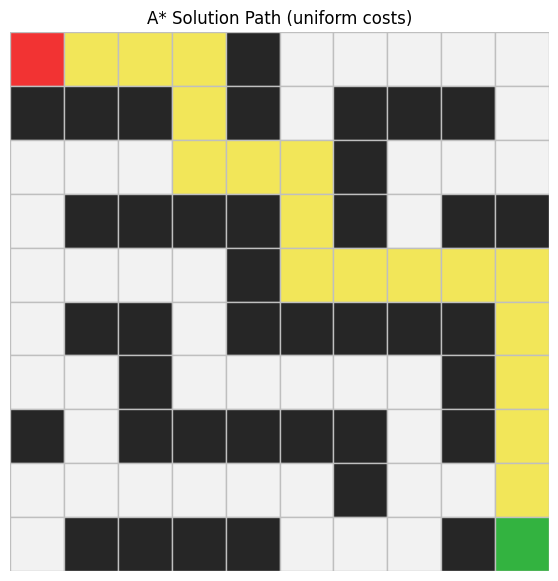

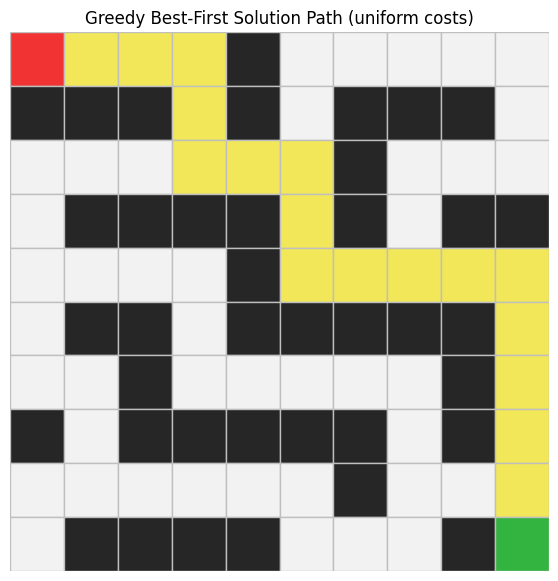

In [93]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [94]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,UCS,success,None,10,10,26,35,0
1,A*,success,None,10,10,25,34,0
2,Weighted A* (W=2),success,None,10,10,13,26,0
3,Greedy,success,None,6,30,6,19,0


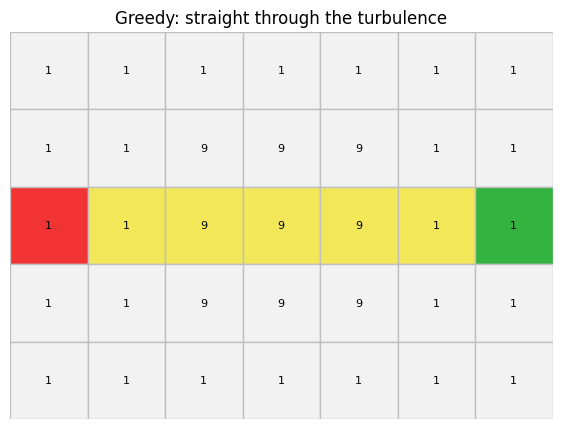

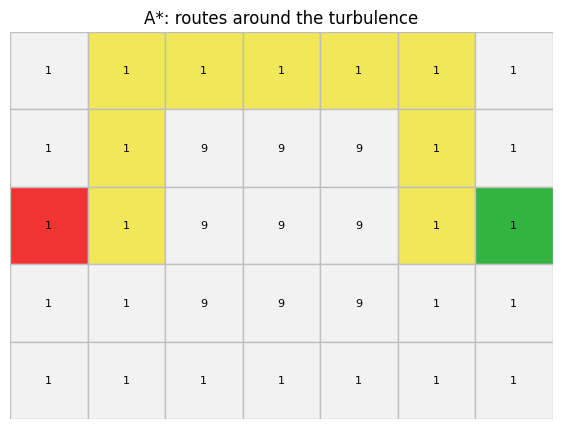

In [95]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [96]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    def h(state, goal):
      return factor * manhattan_distance(state, goal)
    return h
    raise NotImplementedError("Complete inflated_heuristic")


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,A* admissible (uniform map),success,None,18,18,18,23,0
1,A* inflated x3 (uniform map),success,None,18,18,18,23,0
2,A* admissible (mild turbulence),success,None,10,10,29,35,0
3,A* inflated x3 (mild turbulence),success,None,6,12,6,19,0


In [97]:
"""Record your observations in a markdown cell here:

On which map(s) did the inflated heuristic return a suboptimal path? By how much?
The map returned a suboptimal path on the A* inflated(mild turbulence), because the A* admissible (mild turbulence) cost 10, while
Inflated A* (x3): solution cost = 12
 so it is suboptimal by (12 − 10) = 2 cost units
On the uniform map, both methods found the same optimal cost (18), so there was no suboptimality there.

How many fewer nodes did it expand?
A* inflatedx3 (mild turbulence) expanded 6 nodes and A* admissible (mild turbulence) expanded 29 nodes
so the fewer nodes = 29 -6 = 23

In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?
Your answer: When the speed to reaching the goal matters more than the optimallity of the solution"""

"Record your observations in a markdown cell here:\n\nOn which map(s) did the inflated heuristic return a suboptimal path? By how much?\nThe map returned a suboptimal path on the A* inflated(mild turbulence), because the A* admissible (mild turbulence) cost 10, while  \nInflated A* (x3): solution cost = 12\n so it is suboptimal by (12 − 10) = 2 cost units\nOn the uniform map, both methods found the same optimal cost (18), so there was no suboptimality there.\n\nHow many fewer nodes did it expand?\nA* inflatedx3 (mild turbulence) expanded 6 nodes and A* admissible (mild turbulence) expanded 29 nodes\nso the fewer nodes = 29 -6 = 23\n\nIn one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?\nYour answer: When the speed to reaching the goal matters more than the optimallity of the solution"

In [98]:
"""class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).
        node = Node(problem.initial_state())
        limit = self.h(node.state, problem.goal)
        while True:
          result, next_limit = self.f_limited_search(node, limit, problem)
          if isinstance(result, Node):
            return SearchResult(
              algorithm=self.algorithm_name,
              status="success",
              solution=result,
              nodes_expanded=0,
              max_frontier_size=0
    )
          if next_limit == float("inf"):
            return SearchResult(
                algorithm=self.algorithm_name,
                status="failure",
                solution=None,
                nodes_expanded=0,
                max_frontier_size=0
            )

        raise NotImplementedError("Complete IDAStarSearch.search (bonus)")


# After completing the bonus, compare IDA* with A* here:
# ida = IDAStarSearch(manhattan_distance)
# show_results([astar.search(uniform_problem), ida.search(uniform_problem)])"""

'class IDAStarSearch(SearchAlgorithm):\n    algorithm_name = "IDA*"\n\n    def __init__(self, heuristic):\n        self.heuristic = heuristic\n\n    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:\n        # TODO 9 (BONUS, optional):\n        # Implement IDA* following the pseudocode guide above.\n        #\n        # Requirements:\n        # 1. Start with limit = h(initial state).\n        # 2. Each iteration performs a recursive f-limited depth-first search\n        #    that uses path-cycle checking (reuse the idea from DLS in Part A:\n        #    skip a child whose state already appears on the current path).\n        # 3. Track total nodes_expanded across all iterations and the maximum\n        #    recursion depth as max_frontier_size.\n        # 4. Keep an iteration log of (limit, outcome) pairs in\n        #    SearchResult.iterations.\n        # 5. Return status "success", "failure" (next limit is infinity), or\n        #    "cutoff" (max_iterati

In [99]:
# TODO 10:
# Create your first custom map here.

 # Replace this with your own grid.
custom_grid_11 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

# Terrain costs (same shape as the grid), if using WeightedGridProblem.
custom_costs_11 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]


custom_start_11 = (0, 7)
custom_goal_11 = (14, 7)

custom_Problem_11 = WeightedGridProblem(
    custom_grid_11, custom_start_11, custom_goal_11, terrain_costs = custom_costs_11, )

custom_results_11 = [ucs.search(custom_Problem_11),
    astar.search(custom_Problem_11),
    wastar2.search(custom_Problem_11),
    greedy.search(custom_Problem_11),]

show_results(custom_results_11)

# Example after completing:
# custom_problem_1 = WeightedGridProblem(
#     custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
# )
# custom_results_1 = [
#     ucs.search(custom_problem_1),
#     astar.search(custom_problem_1),
#     wastar2.search(custom_problem_1),
#     greedy.search(custom_problem_1),
# ]
# show_results(custom_results_1)



,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,UCS,success,None,18,18,182,198,0
1,A*,success,None,18,18,45,67,0
2,Weighted A* (W=2),success,None,18,18,34,57,0
3,Greedy,success,None,18,90,29,51,0


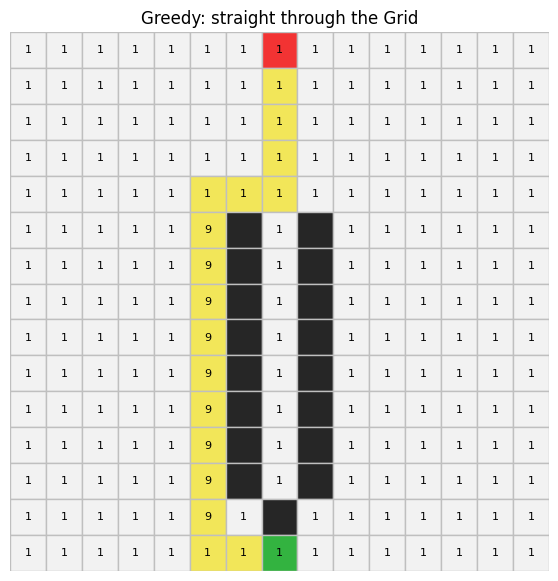

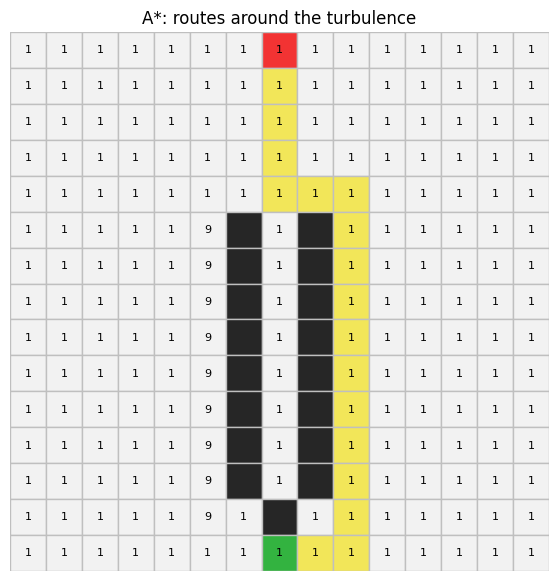

In [100]:
plot_path(
    custom_grid_11,
    custom_start_11,
    custom_goal_11,
    path=custom_results_11[3].path,
    terrain_costs=custom_costs_11,
    title="Greedy: straight through the Grid",
)

plot_path(
    custom_grid_11,
    custom_start_11,
    custom_goal_11,
    path=custom_results_11[1].path,
    terrain_costs=custom_costs_11,
    title="A*: routes around the turbulence",
)


In [101]:
# TODO 11:
# Create your second custom map here.

# Replace this with your own grid.
custom_grid_22 = [
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
]

 # Terrain costs (same shape as the grid), if using WeightedGridProblem
custom_costs_22 = [
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]


custom_start_22 = (0, 0)
custom_goal_22 = (14, 14)

custom_problem_22 = WeightedGridProblem(
     custom_grid_22, custom_start_22, custom_goal_22, terrain_costs=custom_costs_22
 )

custom_results_22 = [
    ucs.search(custom_problem_22),
    astar.search(custom_problem_22),
    wastar2.search(custom_problem_22),
    greedy.search(custom_problem_22), ]

show_results(custom_results_22)
# Example after completing:
# custom_problem_2 = WeightedGridProblem(
#     custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
# )
# custom_results_2 = [
#     ucs.search(custom_problem_2),
#     astar.search(custom_problem_2),
#     wastar2.search(custom_problem_2),
#     greedy.search(custom_problem_2),
# ]
# show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,UCS,success,None,76,84,147,148,0
1,A*,success,None,76,84,138,142,0
2,Weighted A* (W=2),success,None,76,84,150,142,0
3,Greedy,success,None,94,102,195,128,0


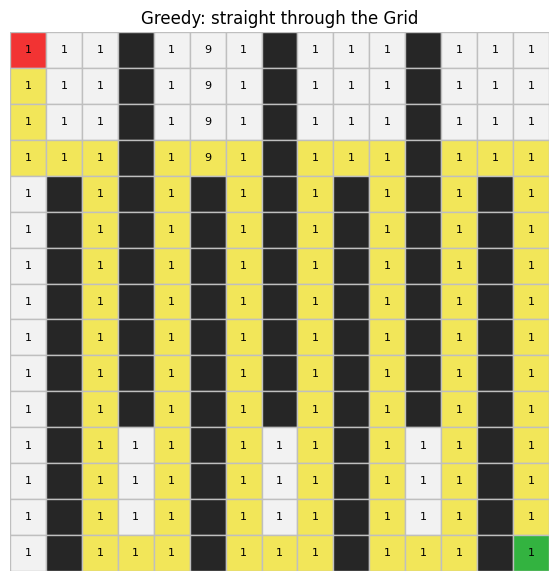

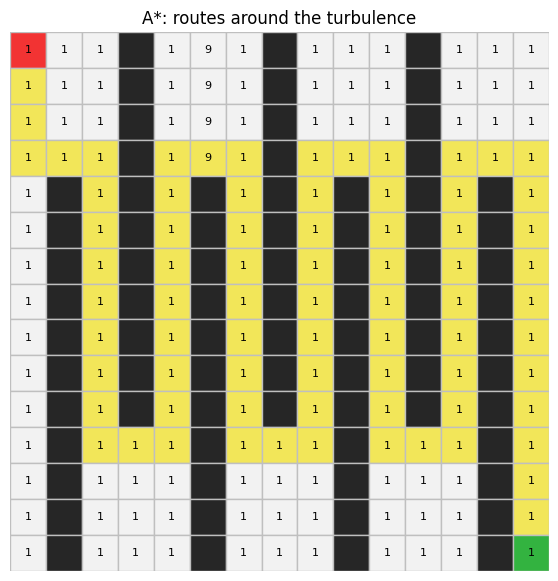

In [102]:
plot_path(
    custom_grid_22,
    custom_start_22,
    custom_goal_22,
    path=custom_results_22[3].path,
    terrain_costs=custom_costs_22,
    title="Greedy: straight through the Grid",
)

plot_path(
    custom_grid_22,
    custom_start_22,
    custom_goal_22,
    path=custom_results_22[1].path,
    terrain_costs=custom_costs_22,
    title="A*: routes around the turbulence",
)

In [103]:
"""Heuristic Functions
1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?
h(n) estimates the cost of action from the current state to the goal. It's knowledge comes from the problem.

2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does
that relaxation remove
The real problem restricts movement to only four directions with walls as barriers but in  the Manhattan distance the walls are removed,
and all costs are equal to one, whereas in the real problem, different cells cost differently.

3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict
    about nodes expanded?
    Manhattan distance dominates Euclidean distance; Manhattan distance is always greater than or equal to the Euclidean distance.
    The one that dominates expands fewer nodes as compare to the non dominant one, Manhattan and Euclidean distance respectively.

4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a
    terrain cost of 0.5?
    Manhattan distance assumes every move costs at least 1. For it to stay admissible , the real cheapest possible move must also cost
    at least 1 otherwise Manhattan's estimate could end up higher than the actual cheapest path."""

'Heuristic Functions\n1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?\nh(n) estimates the cost of action from the current state to the goal. It\'s knowledge comes from the problem.\n\n2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does \nthat relaxation remove\nThe real problem restricts movement to only four directions with walls as barriers but in  the Manhattan distance the walls are removed, \nand all costs are equal to one, whereas in the real problem, different cells cost differently.\n\n3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict \n    about nodes expanded?\n    Manhattan distance dominates Euclidean distance; Manhattan distance is always greater than or equal to the Euclidean distance. \n    The one that dominates expands fewer nodes as compare to the non dominant on

In [104]:
"""Greedy Best-First Search
1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?
    It ignores g(n) (the cost from the start to the current state), the trubulence map made it pay more cost than A*
    since it is following the shortest distance.

2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?
    Greedy may expand fewer nodes but pays more total cost. A* might expand more nodes but pays less cost so "Better algorithm" depends
    on what you're optimizing for. Greedy wins on one, A* wins on the other, and "better" depends entirely on which one
    your mission actually cares about. And on the grid greedy expanded fewer nodes, it paid a cost of 30, while A* paid a cost of 10.


3. Describe a drone mission where Greedy's behaviour would actually be acceptable.
    When there is an emergency rescue, like the walls of the mining pits collapse on the miners and the drone needs to find the loctaion
    of the mining sector as soon as possible to make the rescue possible"""

'Greedy Best-First Search\n1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?\n    It ignores g(n) (the cost from the start to the current state), the trubulence map made it pay more cost than A* \n    since it is following the shortest distance. \n\n2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?\n    Greedy may expand fewer nodes but pays more total cost. A* might expand more nodes but pays less cost so "Better algorithm" depends \n    on what you\'re optimizing for. Greedy wins on one, A* wins on the other, and "better" depends entirely on which one \n    your mission actually cares about. And on the grid greedy expanded fewer nodes, it paid a cost of 30, while A* paid a cost of 10.\n    \n\n3. Describe a drone mission where Greedy\'s behaviour would actually be acceptable.\n    When there is an emergency rescue, like the walls of the mining pits collapse on the miners and the drone ne

In [105]:
""" A* Search
1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.
    f(n) is the total estimated cost the drone will pay from the start of its search to the goal state. g(n) is the cost the drone has
    alredy paid for from the start to the current state of the drone, and h(n) is the estimated cost from the current state of the drone
    to the goal state.

2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on
    the turbulence map?
    When a node is generated, you only know one possible path that reaches it, you don't yet know if it's the cheapest path to that state.
    If you tested at generation time instead, you would return the first path that happens to touch the goal cell not necessarily the
    cheapest one. On the turbulence map if a child node lands exactly on the goal by cutting straight through the
    cost-9 block, while a cheaper path around the block has not been expanded yet, an early goal test would use the expensive path to
    the goal state  and never giving the cheaper route the chance to be considered

3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?
     BFS in Part A used a plain set because all paths cost the same, and in this problem paths have different cost, so the reach has to
     store the nodes with their path cost so you can compare path cost of nodes to each other and choose the best one.

4. Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?
    The UCS expands more nodes than the A* to solve the same problem, this demonstrate how much extra information the heuristics
    provides, because the UCS uses only g(n) it expands the nodes blindly and it sometimes drift far away from the goal state,
    the h(n) make the A* to expand nodes towards the goal state. """

" A* Search\n1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.\n    f(n) is the total estimated cost the drone will pay from the start of its search to the goal state. g(n) is the cost the drone has \n    alredy paid for from the start to the current state of the drone, and h(n) is the estimated cost from the current state of the drone \n    to the goal state.\n\n2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on \n    the turbulence map?\n    When a node is generated, you only know one possible path that reaches it, you don't yet know if it's the cheapest path to that state.\n    If you tested at generation time instead, you would return the first path that happens to touch the goal cell not necessarily the \n    cheapest one. On the turbulence map if a child node lands exactly on the goal by cutting straight through the \n    cost-9 block, while a cheaper path around the bl

In [106]:
"""Admissibility and Consistency
1. State the definitions of admissible and consistent. Which implies which?
    Admissibilty: Means you do not overestimates the cost to reach the goal (more than the actual cost), which is seen as h(n) <= h*(n).
    Consistency implies admissibility but not the reverse.

2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?
   It shows that once that admissible heuristic is taken away the path cost to the solution will be higher than the A* with admissible
   heuristics even if it expands fewer nodes.

3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move
    and explain.
    Yes, Manhattan distance is consistent on the unit-cost grid.
    Because a single move changes only one coordinate by 1, so h(n) can only change by exactly + or - 1 per move. Since every move also costs exactly c(n,a,n') = 1"""

"Admissibility and Consistency\n1. State the definitions of admissible and consistent. Which implies which?\n    Admissibilty: Means you do not overestimates the cost to reach the goal (more than the actual cost), which is seen as h(n) <= h*(n). \n    Consistency implies admissibility but not the reverse.\n\n2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?\n   It shows that once that admissible heuristic is taken away the path cost to the solution will be higher than the A* with admissible \n   heuristics even if it expands fewer nodes. \n\n3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move \n    and explain.\n    Yes, Manhattan distance is consistent on the unit-cost grid.\n    Because a single move changes only one coordinate by 1, so h(n) can only change by exactly + or - 1 per move. Since every move also costs exactly c(n,a,n') = 1"

In [107]:
 """Weighted A* and Trade-offs
 1. How does the weight W interpolate between UCS, A*, and Greedy?
    When the W is zero the A* is the same as the UCS and when it is one or a moderate number it differs from the UCS,
    when the W is infinity or relatively larger number the g(n) turns to be negligible and do not show much in the function
    in this case the A* behaves like the Greedy

2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?
    It guarantee that a solution found by Weighted A* with weight W using an admissible h has cost at most W times the optimal cost.
    With W=2, that's a guarantee of being within 2× optimal

3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?
    I would choose a weighted A* with a W = 2, because in this case optimality does not really matter but speed does, I would have chosen
    Greedy because it expands fewer nodes and faster but it is not quality guarantee, but weighted A* does and also expands fewer nodes as
    compare to strict A*"""

"Weighted A* and Trade-offs\n1. How does the weight W interpolate between UCS, A*, and Greedy?\n   When the W is zero the A* is the same as the UCS and when it is one or a moderate number it differs from the UCS, \n   when the W is infinity or relatively larger number the g(n) turns to be negligible and do not show much in the function \n   in this case the A* behaves like the Greedy\n\n2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?\n   It guarantee that a solution found by Weighted A* with weight W using an admissible h has cost at most W times the optimal cost. \n   With W=2, that's a guarantee of being within 2× optimal\n\n3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?\n   I would choose a weighted A* with a W = 2, because in this case optimality does not really matter but speed does, I would have chosen \n   Greedy because it expands 

In [108]:
"""Memory and Real-World Drone Context
1.Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?
    The priority key and the dictionary A* uses as its frontier and reached respectively, because they hold all nodes generated in
    them and do not discard them untill they are expanded. The IDA avoids it by not keeping the generated nodes in it's frontier,
    it does plain depth-first search, bounded by an f-cost limit, so the only things they keep is the current path. which ever path
    that was explored and the goal wasn't found is discarded and starts a new search. The price it pays, it re-expands the same
    nodes repeatedly, once per outer-loop iteration, since each f-limit increase restarts the DFS from scratch. So it trades memory
    for redundant computation

2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts,
    no-fly zones that change over time, battery state)?
    Weather forecasts: wind resistance, rain, or turbulence that changes the actual energy cost of flying through a region,
    and which changes over time, not just by location.
    No-fly zones that shift dynamically: temporary restrictions (e.g. another aircraft, an event, a wildfire) that aren't fixed walls
    but appear/disappear during the flight.
    Battery state: the cost of a route isn't just distance/terrain, it's whether the battery can physically survive it; a cell that's
    "cheap" in distance terms might be unreachable if it requires climbing altitude the battery can't support.

3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts
    (e.g., learned heuristics, real-time search) become relevant?
    The drone might not be able to reach the goal because it is only targeting and moving towards the direction that the goal was said
    to be, so if the goal state changes, then the drone will only be using a wrong heuristic to track the goal, which might lead it to
    the wrong destination. In this case real time searh becomes relevant,

4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?
    I would ship A* on the drone, because it is guarantee optimality and cheapest path so far as the heuristics is admissible.
    I would reconsider when the problem is very huge and the memory capcity to the problem is relatively low, since A* takes up much space."""

'Memory and Real-World Drone Context\n1.Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?\n    The priority key and the dictionary A* uses as its frontier and reached respectively, because they hold all nodes generated in \n    them and do not discard them untill they are expanded. The IDA avoids it by not keeping the generated nodes in it\'s frontier, \n    it does plain depth-first search, bounded by an f-cost limit, so the only things they keep is the current path. which ever path \n    that was explored and the goal wasn\'t found is discarded and starts a new search. The price it pays, it re-expands the same \n    nodes repeatedly, once per outer-loop iteration, since each f-limit increase restarts the DFS from scratch. So it trades memory \n    for redundant computation  \n\n2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, \n    no-fly zones